/opt/anaconda3/lib/python3.12/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


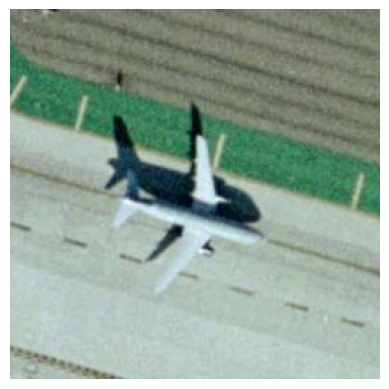

In [26]:
import rasterio
import matplotlib.pyplot as plt

# Load a DLRSD image
image_path = "DLRSD/Images/airplane/airplane01.tif"
with rasterio.open(image_path) as src:
    image = src.read()

# Display the image (assuming it's RGB)
plt.imshow(image.transpose(1, 2, 0))  # Rearrange channels for visualization
plt.axis("off")
plt.show()


In [27]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Concatenate, Input
from tensorflow.keras.models import Model
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ---------------------------
# 1️⃣ Load and Preprocess Data
# ---------------------------
IMAGE_SIZE = (256, 256)  # Resize images
DATASET_PATH = "/Users/varunkarthik/Documents/mit_proj/DLRSD"  # Update with actual path

def load_images_and_masks(image_dir, mask_dir, image_size=IMAGE_SIZE):
    images, masks = [], []
    image_files = sorted(os.listdir(image_dir))
    mask_files = sorted(os.listdir(mask_dir))

    for img_file, mask_file in zip(image_files, mask_files):
        # Read image & mask
        img = cv2.imread(os.path.join(image_dir, img_file))
        mask = cv2.imread(os.path.join(mask_dir, mask_file), cv2.IMREAD_GRAYSCALE)  # Read as grayscale

        # Resize
        img = cv2.resize(img, image_size)
        mask = cv2.resize(mask, image_size)

        # Normalize
        img = img / 255.0  # Normalize image
        mask = mask / 255.0  # Normalize mask (values 0 or 1)
        
        # Expand dimensions for compatibility
        mask = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

# Paths to images and masks (Update paths)
image_dir = os.path.join(DATASET_PATH, "images")
mask_dir = os.path.join(DATASET_PATH, "masks")

# Load dataset
X, Y = load_images_and_masks(image_dir, mask_dir)

# Split data (80% Train, 20% Test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# ---------------------------
# 2️⃣ Define U-Net Model
# ---------------------------
def unet(input_shape=(256, 256, 3)):
    inputs = Input(input_shape)

    # Encoder
    c1 = Conv2D(64, (3, 3), activation="relu", padding="same")(inputs)
    c1 = Conv2D(64, (3, 3), activation="relu", padding="same")(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, (3, 3), activation="relu", padding="same")(p1)
    c2 = Conv2D(128, (3, 3), activation="relu", padding="same")(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(256, (3, 3), activation="relu", padding="same")(p2)
    c3 = Conv2D(256, (3, 3), activation="relu", padding="same")(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(512, (3, 3), activation="relu", padding="same")(p3)
    c4 = Conv2D(512, (3, 3), activation="relu", padding="same")(c4)
    p4 = MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = Conv2D(1024, (3, 3), activation="relu", padding="same")(p4)
    c5 = Conv2D(1024, (3, 3), activation="relu", padding="same")(c5)

    # Decoder
    u6 = UpSampling2D((2, 2))(c5)
    u6 = Concatenate()([u6, c4])
    c6 = Conv2D(512, (3, 3), activation="relu", padding="same")(u6)
    c6 = Conv2D(512, (3, 3), activation="relu", padding="same")(c6)

    u7 = UpSampling2D((2, 2))(c6)
    u7 = Concatenate()([u7, c3])
    c7 = Conv2D(256, (3, 3), activation="relu", padding="same")(u7)
    c7 = Conv2D(256, (3, 3), activation="relu", padding="same")(c7)

    u8 = UpSampling2D((2, 2))(c7)
    u8 = Concatenate()([u8, c2])
    c8 = Conv2D(128, (3, 3), activation="relu", padding="same")(u8)
    c8 = Conv2D(128, (3, 3), activation="relu", padding="same")(c8)

    u9 = UpSampling2D((2, 2))(c8)
    u9 = Concatenate()([u9, c1])
    c9 = Conv2D(64, (3, 3), activation="relu", padding="same")(u9)
    c9 = Conv2D(64, (3, 3), activation="relu", padding="same")(c9)

    outputs = Conv2D(1, (1, 1), activation="sigmoid")(c9)

    model = Model(inputs, outputs)
    return model

# Create model
model = unet()
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# ---------------------------
# 3️⃣ Train the Model
# ---------------------------
EPOCHS = 20
BATCH_SIZE = 8

history = model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS
)

# ---------------------------
# 4️⃣ Evaluate & Predict
# ---------------------------
# Evaluate Model
loss, acc = model.evaluate(X_test, Y_test)
print(f"Test Accuracy: {acc:.4f}")

# Predict on Test Image
idx = np.random.randint(0, len(X_test))
test_img = X_test[idx]
test_mask = Y_test[idx]

predicted_mask = model.predict(np.expand_dims(test_img, axis=0))[0]

# Plot Results
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(test_img)
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(test_mask[:, :, 0], cmap="gray")
plt.title("Ground Truth Mask")

plt.subplot(1, 3, 3)
plt.imshow(predicted_mask[:, :, 0], cmap="gray")
plt.title("Predicted Mask")

plt.show()


error: OpenCV(4.11.0) /Users/xperience/GHA-Actions-OpenCV/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


boobs code 

In [34]:
import os
import cv2
import numpy as np

from matplotlib import pyplot as plt
from patchify import patchify
from PIL import Image
from tensorflow.keras.metrics import MeanIoU

from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = MinMaxScaler()

root_directory = '/Users/varunkarthik/Documents/mit_proj/DLRSD'

patch_size = 256










############################################################################

In [38]:
import os
import cv2
import numpy as np
from PIL import Image
from sklearn.preprocessing import MinMaxScaler

root_directory = '/Users/varunkarthik/Documents/mit_proj/DLRSD'
patch_size = 256
scaler = MinMaxScaler()

image_dataset = []
imgs = ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential',
        'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark',
        'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']

# Collect all image paths in a sorted order
image_paths = []
for path, subdirs, files in sorted(os.walk(root_directory)):
    dirname = path.split(os.path.sep)[-1]
    if dirname in imgs:
        images = [image_name for image_name in sorted(files) if image_name.endswith(".tif")]
        image_paths.extend([os.path.join(path, image_name) for image_name in images])

# Process images in sorted order
for image_path in image_paths:
    image = cv2.imread(image_path, 1)
    SIZE_X = (image.shape[1] // patch_size) * patch_size
    SIZE_Y = (image.shape[0] // patch_size) * patch_size
    image = Image.fromarray(image)
    image = image.crop((0, 0, SIZE_X, SIZE_Y))
    image = np.array(image)

    print("Now patchifying image:", image_path)
    patches_img = patchify(image, (patch_size, patch_size, 3), step=patch_size)

    for i in range(patches_img.shape[0]):
        for j in range(patches_img.shape[1]):
            single_patch_img = patches_img[i, j, :, :]

            single_patch_img = scaler.fit_transform(single_patch_img.reshape(-1, single_patch_img.shape[-1])).reshape(single_patch_img.shape)
            single_patch_img = single_patch_img[0]

            image_dataset.append(single_patch_img)

Now patchifying image: /Users/varunkarthik/Documents/mit_proj/DLRSD/images/agricultural/agricultural00.tif
Now patchifying image: /Users/varunkarthik/Documents/mit_proj/DLRSD/images/agricultural/agricultural01.tif
Now patchifying image: /Users/varunkarthik/Documents/mit_proj/DLRSD/images/agricultural/agricultural02.tif
Now patchifying image: /Users/varunkarthik/Documents/mit_proj/DLRSD/images/agricultural/agricultural03.tif
Now patchifying image: /Users/varunkarthik/Documents/mit_proj/DLRSD/images/agricultural/agricultural04.tif
Now patchifying image: /Users/varunkarthik/Documents/mit_proj/DLRSD/images/agricultural/agricultural05.tif
Now patchifying image: /Users/varunkarthik/Documents/mit_proj/DLRSD/images/agricultural/agricultural06.tif
Now patchifying image: /Users/varunkarthik/Documents/mit_proj/DLRSD/images/agricultural/agricultural07.tif
Now patchifying image: /Users/varunkarthik/Documents/mit_proj/DLRSD/images/agricultural/agricultural08.tif
Now patchifying image: /Users/varunka

In [39]:
mask_dataset = []
for path, subdirs, files in sorted(os.walk(root_directory)):
    dirname = path.split(os.path.sep)[-1]
    if dirname in imgs:
        masks = [mask_name for mask_name in sorted(files) if mask_name.endswith(".png")]
        for mask_name in masks:
            mask = cv2.imread(os.path.join(path, mask_name), 1)
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
            SIZE_X = (mask.shape[1] // patch_size) * patch_size
            SIZE_Y = (mask.shape[0] // patch_size) * patch_size
            mask = Image.fromarray(mask)
            mask = mask.crop((0, 0, SIZE_X, SIZE_Y))
            mask = np.array(mask)

            print("Now patchifying mask:", os.path.join(path, mask_name))
            patches_mask = patchify(mask, (patch_size, patch_size, 3), step=patch_size)

            for i in range(patches_mask.shape[0]):
                for j in range(patches_mask.shape[1]):
                    single_patch_mask = patches_mask[i, j, :, :]
                    mask_dataset.append(single_patch_mask)

Now patchifying mask: /Users/varunkarthik/Documents/mit_proj/DLRSD/masks/agricultural/agricultural00.png
Now patchifying mask: /Users/varunkarthik/Documents/mit_proj/DLRSD/masks/agricultural/agricultural01.png
Now patchifying mask: /Users/varunkarthik/Documents/mit_proj/DLRSD/masks/agricultural/agricultural02.png
Now patchifying mask: /Users/varunkarthik/Documents/mit_proj/DLRSD/masks/agricultural/agricultural03.png
Now patchifying mask: /Users/varunkarthik/Documents/mit_proj/DLRSD/masks/agricultural/agricultural04.png
Now patchifying mask: /Users/varunkarthik/Documents/mit_proj/DLRSD/masks/agricultural/agricultural05.png
Now patchifying mask: /Users/varunkarthik/Documents/mit_proj/DLRSD/masks/agricultural/agricultural06.png
Now patchifying mask: /Users/varunkarthik/Documents/mit_proj/DLRSD/masks/agricultural/agricultural07.png
Now patchifying mask: /Users/varunkarthik/Documents/mit_proj/DLRSD/masks/agricultural/agricultural08.png
Now patchifying mask: /Users/varunkarthik/Documents/mit

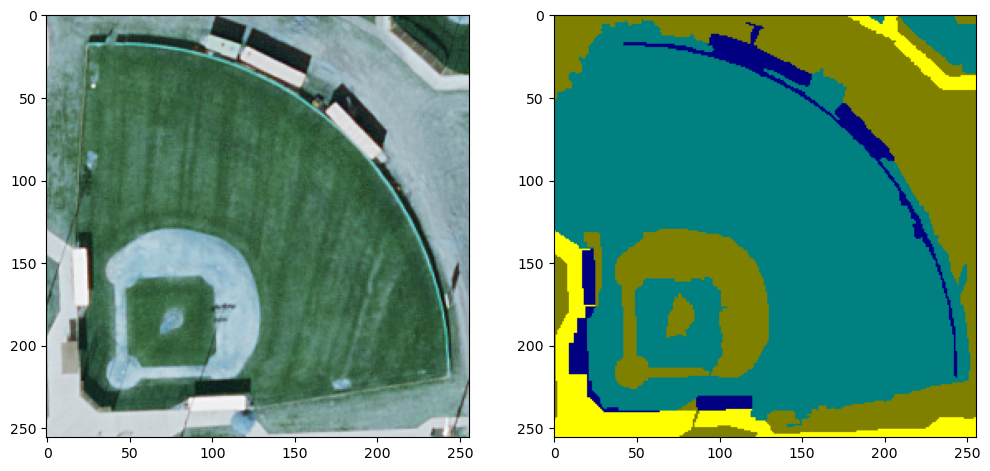

In [ ]:
image_dataset = np.array(image_dataset)
mask_dataset =  np.array(mask_dataset)

#Sanity check, view few mages
import random
import numpy as np
image_number = random.randint(0, len(image_dataset))
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(np.reshape(image_dataset[image_number], (patch_size, patch_size, 3)))
plt.subplot(122)
plt.imshow(np.reshape(mask_dataset[image_number], (patch_size, patch_size, 3)))
plt.show(10)

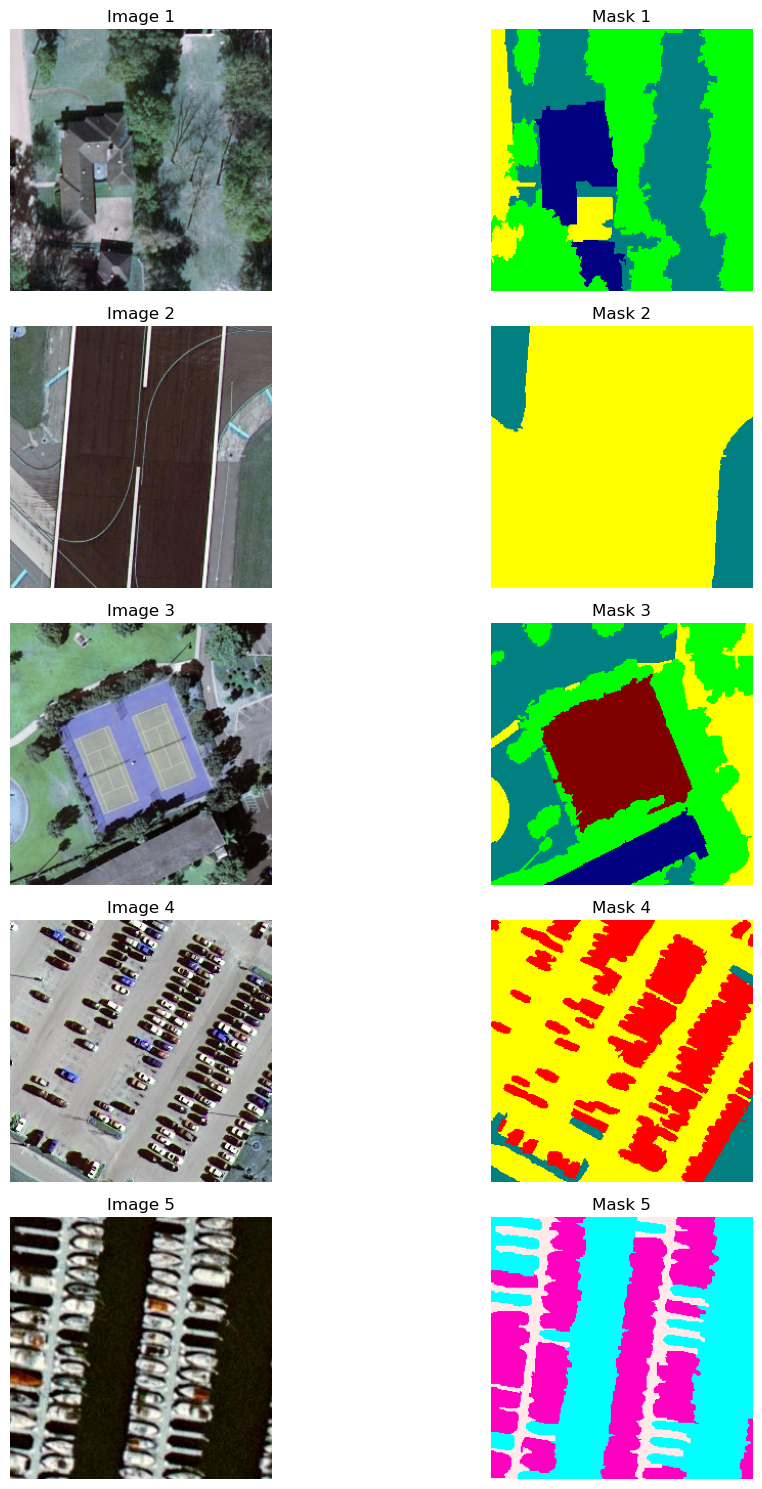

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Convert lists to NumPy arrays (if not already done)
image_dataset = np.array(image_dataset)
mask_dataset = np.array(mask_dataset)

# Number of images to display
num_images = 5

# Create figure with appropriate size
plt.figure(figsize=(12, num_images * 3))

for i in range(num_images):
    image_number = random.randint(0, len(image_dataset) - 1)  # Random image index

    # Display Image
    plt.subplot(num_images, 2, 2 * i + 1)
    plt.imshow(np.reshape(image_dataset[image_number], (patch_size, patch_size, 3)))
    plt.title(f"Image {i+1}")
    plt.axis("off")

    # Display Corresponding Mask
    plt.subplot(num_images, 2, 2 * i + 2)
    plt.imshow(np.reshape(mask_dataset[image_number], (patch_size, patch_size, 3)), cmap="gray")
    plt.title(f"Mask {i+1}")
    plt.axis("off")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [43]:
mask_dataset.shape

(2100, 1, 256, 256, 3)

In [44]:
airplane = [166,202,240]
bare_soil = [128,128,0] 
buildings = [0,0,128]
cars = [255,0,0]
chaparral = [0,128,0]
court = [128,0,0]
dock = [255,233,233]
field = [160,160,164]
grass = [0,128,128]
mobile_home = [90,87,255]
pavement = [255,255,0]
sand = [255,192,0]
sea =[0,0,255]
ship = [255,0,192]
tanks = [128,0,128]
trees = [0, 255, 0]
water = [255,0,255]

label = single_patch_mask

In [45]:
def rgb_to_2D_label(label):
    """
    Supply our label masks as input in RGB format. 
    Replace pixels with specific RGB values...
    """
    label_seg = np.zeros(label.shape[1:3], dtype=np.uint8)

    # Define RGB values for classes
    classes = {
        (166, 202, 240): 1,   # airplane
        (128, 128, 0): 2,     # bare_soil
        (0, 0, 128): 3,       # buildings
        (255, 0, 0): 4,       # cars
        (0, 128, 0): 5,       # chaparral
        (128, 0, 0): 6,       # court
        (255, 233, 233): 7,   # dock
        (160, 160, 164): 8,   # field
        (0, 128, 128): 9,     # grass
        (90, 87, 255): 10,    # mobile_home
        (255, 255, 0): 11,    # pavement
        (255, 192, 0): 12,    # sand
        (0, 0, 255): 13,      # sea
        (255, 0,192): 14,    # ship
        (128, 0, 128): 15,    # tanks
        (0, 255, 0): 16,      # trees
        (0, 255, 255): 17     # water
    }

    for rgb_class, class_label in classes.items():
        # Create a mask for pixels that match the class RGB values
        mask = np.all(label[0] == np.array(rgb_class).reshape(1, 1, 3), axis=-1)
        label_seg[mask] = class_label

    return label_seg

# Example usage with all images in mask_dataset
labels = []
for i in range(mask_dataset.shape[0]):
    label = rgb_to_2D_label(mask_dataset[i])
    labels.append(label)

labels = np.array(labels)   
labels = np.expand_dims(labels, axis=3)

# Print unique labels in the dataset
print("Unique labels in label dataset are:", np.unique(labels))

Unique labels in label dataset are: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


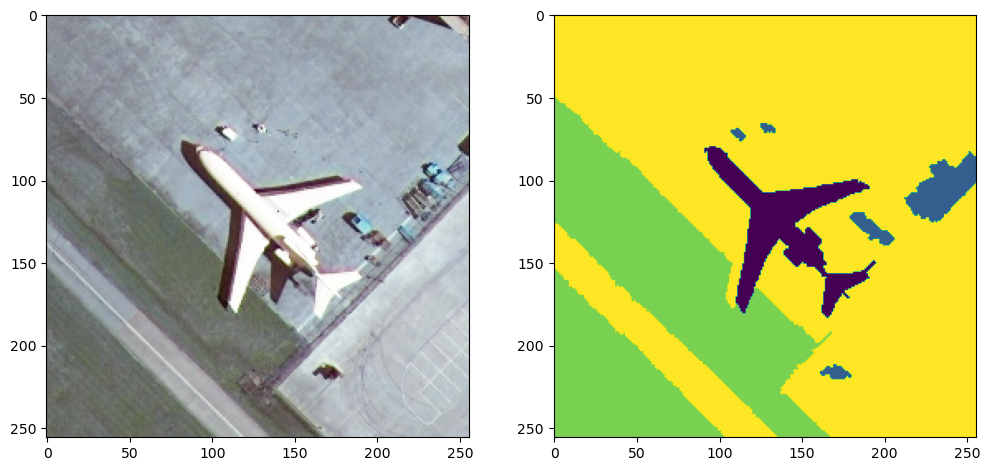

In [51]:
import random
import numpy as np
image_number = random.randint(0, len(image_dataset))
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(image_dataset[image_number])
plt.subplot(122)
plt.imshow(labels[image_number][:,:,0])
plt.show()

In [52]:
num_classes = 18  # Update this value to the correct number of unique classes in your dataset
from keras.utils import to_categorical
labels_cat = to_categorical(labels, num_classes=num_classes)

In [53]:
image_dataset.shape

(2100, 256, 256, 3)

In [54]:
labels_cat.shape

(2100, 256, 256, 18)

In [55]:
def jacard_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) - intersection + 1.0)

In [56]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda
from keras import backend as K

def multi_unet_model(n_classes=18, IMG_HEIGHT=256, IMG_WIDTH=256, IMG_CHANNELS=3):
#Build the model
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    #s = Lambda(lambda x: x / 255)(inputs)   #No need for this if we normalize our inputs beforehand
    s = inputs

    #Contraction path
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(s)
    c1 = Dropout(0.2)(c1)  # Original 0.1
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Dropout(0.2)(c2)  # Original 0.1
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)
     
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)
     
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)
     
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    
    #Expansive path 
    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
     
    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
     
    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = Dropout(0.2)(c8)  # Original 0.1
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
     
    u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = Dropout(0.2)(c9)  # Original 0.1
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
     
    outputs = Conv2D(n_classes, (1, 1), activation='softmax')(c9)
     
    model = Model(inputs=[inputs], outputs=[outputs])
    
    #NOTE: Compile the model in the main program to make it easy to test with various loss functions
    #model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    #model.summary()
    
    return model

In [57]:
model = multi_unet_model()
#model.compile(optimizer='adam')
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    147,584 │ dropout_3[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]  

 Total params: 1,941,394 (7.41 MB)

 Trainable params: 1,941,394 (7.41 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
image_number = random.randint(0, len(image_dataset))
temp = np.reshape(image_dataset[image_number], (patch_size, patch_size, 3))
temp1 = np.expand_dims(temp, axis=0)
unet_mask = model.predict(temp1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [80]:
unet_mask.shape

(1, 256, 256, 18)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


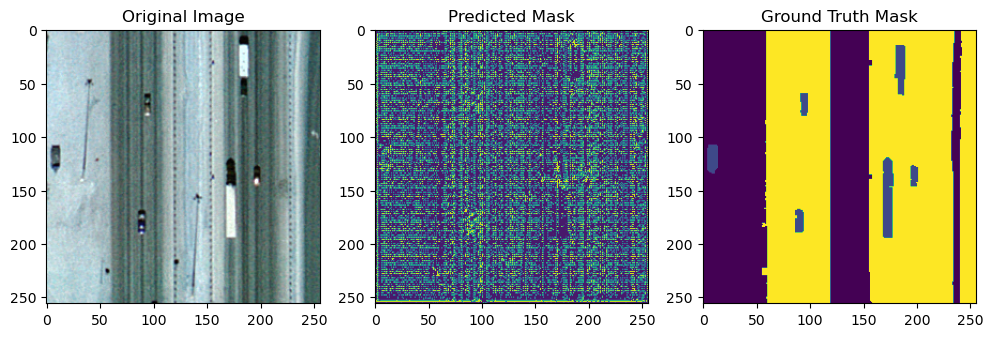

In [81]:
plt.figure(figsize=(12, 6))
input_image= image_dataset[image_number]
# Original Image
plt.subplot(131)
plt.imshow(input_image)
plt.title("Original Image")

# Predicted Mask
plt.subplot(132)
plt.imshow(np.argmax(unet_mask[0], axis=-1), cmap='viridis')
plt.title("Predicted Mask")

# Ground Truth Mask (if available)
# Replace 'ground_truth_masks' with the actual ground truth masks dataset
plt.subplot(133)
plt.imshow(labels[image_number][:,:,0])
plt.title("Ground Truth Mask")

plt.show()

In [82]:
import tensorflow as tf

# Enable mixed precision
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)

In [83]:
def downsample(filters, size, apply_batchnorm=True, input_channels=None):
    initializer = tf.random_normal_initializer(0., 0.02)

    result = tf.keras.Sequential()
    result.add(
        tf.keras.layers.Conv2D(
            filters, size, strides=2, padding='same',
            kernel_initializer=initializer, use_bias=False,
            input_shape=(None, None, input_channels)  # Specify input channels
        )
    )

    if apply_batchnorm:
        result.add(tf.keras.layers.BatchNormalization())

    result.add(tf.keras.layers.LeakyReLU())

    return result

def upsample(filters, size, apply_dropout=False, input_channels=None):
    initializer = tf.random_normal_initializer(0., 0.02)

    result = tf.keras.Sequential()
    result.add(
        tf.keras.layers.Conv2DTranspose(
            filters, size, strides=2, padding='same',
            kernel_initializer=initializer, use_bias=False,
            input_shape=(None, None, input_channels)  # Specify input channels
        )
    )

    result.add(tf.keras.layers.BatchNormalization())

    if apply_dropout:
        result.add(tf.keras.layers.Dropout(0.5))

    result.add(tf.keras.layers.ReLU())

    return result

class Generator(tf.Module):
    def __init__(self, input_channels, output_channels=3):
        self.down_stack = [
            downsample(64, 4, apply_batchnorm=False, input_channels=input_channels),
            downsample(128, 4, input_channels=64),
            downsample(256, 4, input_channels=128),
            downsample(512, 4, input_channels=256),
            downsample(512, 4, input_channels=512),
            downsample(512, 4, input_channels=512),
            downsample(512, 4, input_channels=512),
            downsample(512, 4, input_channels=512),
        ]

        self.up_stack = [
            upsample(512, 4, apply_dropout=True, input_channels=512),
            upsample(512, 4, apply_dropout=True, input_channels=1024),
            upsample(512, 4, apply_dropout=True, input_channels=1024),
            upsample(512, 4, input_channels=1024),
            upsample(256, 4, input_channels=1024),
            upsample(128, 4, input_channels=512),
            upsample(64, 4, input_channels=256),
        ]

        initializer = tf.random_normal_initializer(0., 0.02)
        self.last = tf.keras.layers.Conv2DTranspose(
            output_channels,
            4, strides=2,
            padding='same', kernel_initializer=initializer,
            activation='tanh'
        )

    def __call__(self, x, training=False):
        skips = []
        for down in self.down_stack:
            x = down(x, training=training)
            skips.append(x)
        skips = reversed(skips[:-1])
        for up, skip in zip(self.up_stack, skips):
            x = up(x, training=training)
            x = tf.concat([x, skip], axis=-1)
        x = self.last(x, training=training)
        return x

# Example instantiation
generator = Generator(input_channels=18, output_channels=3)

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv_transpose.py:94: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


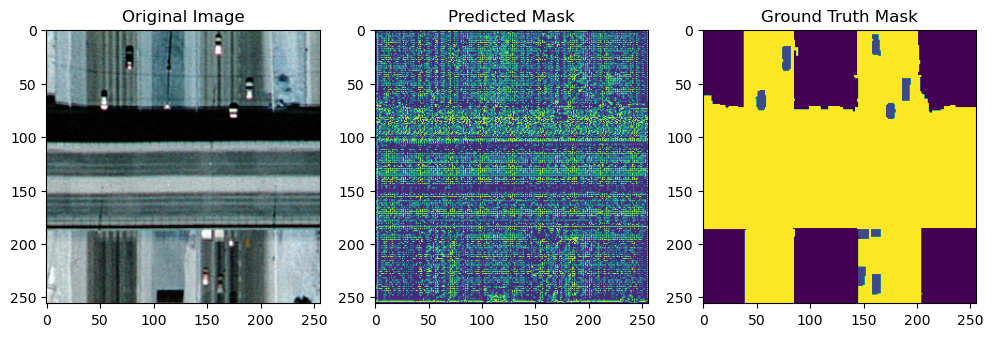

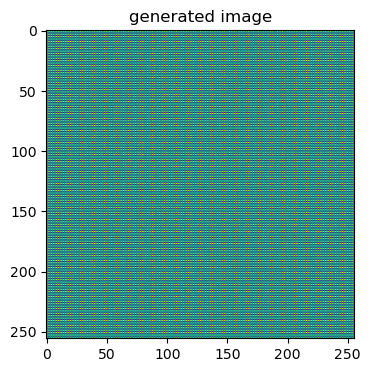

In [87]:
# Provide your UNet-generated mask as input to the generator
image_number = random.randint(0, len(image_dataset))
temp = np.reshape(image_dataset[image_number], (patch_size, patch_size, 3))
temp1 = np.expand_dims(temp, axis=0)
unet_mask = model.predict(temp1)

# Call the generator with the UNet-generated mask
gen_output = generator(unet_mask)

# Display the generated image (you can adapt this based on your display mechanism)
# plt.imshow(generated_image[0].numpy())
# plt.show()
# Selecting the first channel for visualization
# Combining multiple channels (assuming they represent different features)
combined_output = tf.reduce_mean(gen_output[0, :, :, 0:18], axis=-1)  # Taking the mean of the first 3 channels

# Visualize the selected or combined output
plt.figure(figsize=(12, 6))
input_image= image_dataset[image_number]
# Original Image
plt.subplot(131)
plt.imshow(input_image)
plt.title("Original Image")

# Predicted Mask
plt.subplot(132)
plt.imshow(np.argmax(unet_mask[0], axis=-1), cmap='viridis')
plt.title("Predicted Mask")

# Ground Truth Mask (if available)
# Replace 'ground_truth_masks' with the actual ground truth masks dataset
plt.subplot(133)
plt.imshow(labels[image_number][:,:,0])
plt.title("Ground Truth Mask")
plt.show()

plt.figure(figsize=(5,4))
plt.imshow((combined_output + 1) / 2)
plt.title("generated image")
plt.show()

In [88]:
gen_output.shape

TensorShape([1, 256, 256, 3])

In [89]:
input_image.shape

(256, 256, 3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


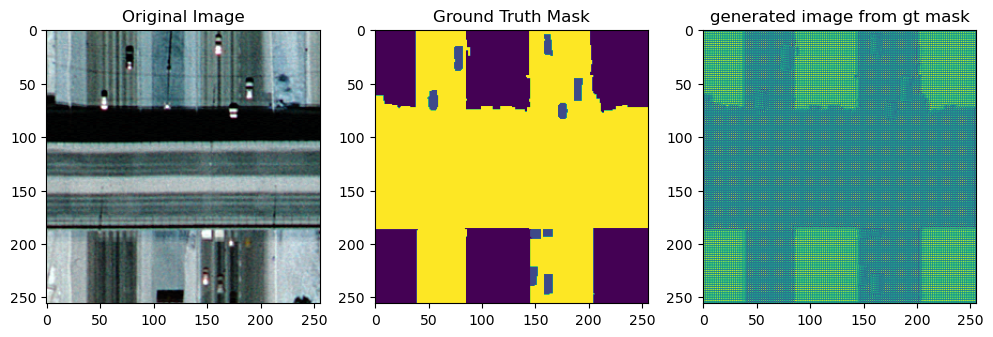

In [90]:
t1 = np.expand_dims(labels_cat[image_number], axis=0)
gen_output = generator(t1)

# Display the generated image (you can adapt this based on your display mechanism)
# plt.imshow(generated_image[0].numpy())
# plt.show()
# Selecting the first channel for visualization
# Combining multiple channels (assuming they represent different features)
combined_output = tf.reduce_mean(gen_output[0, :, :, 0:3], axis=-1)  # Taking the mean of the first 3 channels

# Visualize the selected or combined output
plt.figure(figsize=(12, 6))
input_image= image_dataset[image_number]
# Original Image
plt.subplot(131)
plt.imshow(input_image)
plt.title("Original Image")

# # Predicted Mask
# plt.subplot(132)
# plt.imshow(np.argmax(unet_mask[0], axis=-1), cmap='viridis')
# plt.title("Predicted Mask")

# Ground Truth Mask (if available)
# Replace 'ground_truth_masks' with the actual ground truth masks dataset
plt.subplot(132)
plt.imshow(labels[image_number][:,:,0])
plt.title("Ground Truth Mask")

plt.subplot(133)
plt.imshow((combined_output + 1) / 2)
plt.title("generated image from gt mask")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


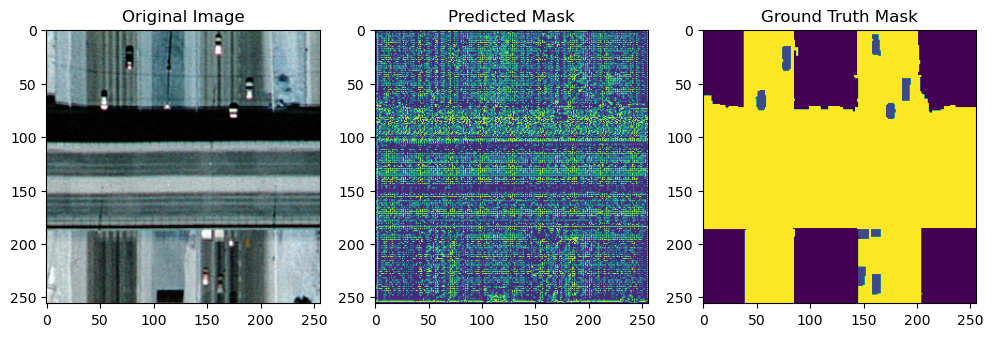

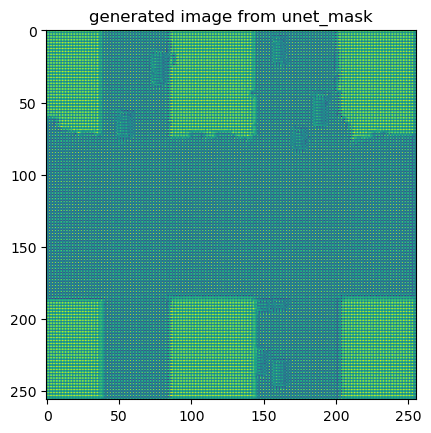

In [91]:
# Visualize the selected or combined output
plt.figure(figsize=(12, 6))
input_image= image_dataset[image_number]
# Original Image
plt.subplot(131)
plt.imshow(input_image)
plt.title("Original Image")

# Predicted Mask
plt.subplot(132)
plt.imshow(np.argmax(unet_mask[0], axis=-1), cmap='viridis')
plt.title("Predicted Mask")

# Ground Truth Mask (if available)
# Replace 'ground_truth_masks' with the actual ground truth masks dataset
plt.subplot(133)
plt.imshow(labels[image_number][:,:,0])
plt.title("Ground Truth Mask")

plt.figure()
plt.imshow((combined_output + 1) / 2)
plt.title("generated image from unet_mask")
plt.show()

In [92]:
combined_output.shape

TensorShape([256, 256])

In [93]:
LAMBDA = 100
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)
seg_loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)  # Assuming segmentation is a categorical task
def generator_loss(disc_generated_output, gen_output, target):
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)

    # Mean absolute error
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))

    total_gen_loss = gan_loss + (LAMBDA * l1_loss)

    return total_gen_loss, gan_loss, l1_loss

In [100]:
from tensorflow.keras.layers import Input, Concatenate, Conv2D, BatchNormalization, LeakyReLU, ZeroPadding2D, Activation
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def define_discriminator(image_shape):
    # weight initialization
    init = RandomNormal(stddev=0.02)

    # source image input
    in_src_image = Input(shape=image_shape)
    # target image input
    in_target_image = Input(shape=image_shape)

    # Concatenate images along the channel axis
    merged = Concatenate()([in_src_image, in_target_image])

    # C64: 4x4 kernel Stride 2x2
    d = Conv2D(64, (4, 4), strides=(2, 2), padding='same', kernel_initializer=init)(merged)
    d = LeakyReLU(alpha=0.2)(d)

    # C128: 4x4 kernel Stride 2x2
    d = Conv2D(128, (4, 4), strides=(2, 2), padding='same', kernel_initializer=init)(d)
    d = BatchNormalization()(d)
    d = LeakyReLU(alpha=0.2)(d)

    # C256: 4x4 kernel Stride 2x2
    d = Conv2D(256, (4, 4), strides=(2, 2), padding='same', kernel_initializer=init)(d)
    d = BatchNormalization()(d)
    d = LeakyReLU(alpha=0.2)(d)

    # C512: 4x4 kernel Stride 2x2
    d = Conv2D(512, (4, 4), strides=(2, 2), padding='same', kernel_initializer=init)(d)
    d = BatchNormalization()(d)
    d = LeakyReLU(alpha=0.2)(d)

    # Second last output layer: 4x4 kernel but Stride 1x1
    d = Conv2D(512, (4, 4), padding='same', kernel_initializer=init)(d)
    d = BatchNormalization()(d)
    d = LeakyReLU(alpha=0.2)(d)

    # Patch output
    d = Conv2D(1, (4, 4), padding='same', kernel_initializer=init)(d)
    patch_out = Activation('sigmoid')(d)

    # Define model
    model = Model([in_src_image, in_target_image], patch_out)

    # Compile model
    opt = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt, loss_weights=[0.5])

    return model

In [101]:
gen_output.shape

TensorShape([1, 256, 256, 3])

In [102]:
input_image.shape

(1, 256, 256, 3)

In [105]:
if len(input_image.shape) == 3:
    input_image = np.expand_dims(input_image, axis=0)  # Convert (256,256,3) → (1,256,256,3)
elif len(input_image.shape) == 5:
    input_image = np.squeeze(input_image, axis=0)  # Convert (1,1,256,256,3) → (1,256,256,3)
input_image.shape

(1, 256, 256, 3)

In [106]:
d_model = define_discriminator((256,256,3))

# Test the discriminator
predictions = d_model.predict([gen_output, input_image])

# Display the output
print("Discriminator Output:")
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Discriminator Output:
[[[[0.4958]
   [0.4937]
   [0.4927]
   [0.4973]
   [0.4956]
   [0.494 ]
   [0.4944]
   [0.4956]
   [0.498 ]
   [0.4932]
   [0.493 ]
   [0.4905]
   [0.4976]
   [0.4976]
   [0.4998]
   [0.4993]]

  [[0.4905]
   [0.4873]
   [0.4888]
   [0.49  ]
   [0.4863]
   [0.488 ]
   [0.4875]
   [0.4915]
   [0.4895]
   [0.4895]
   [0.4875]
   [0.484 ]
   [0.4907]
   [0.4888]
   [0.495 ]
   [0.5   ]]

  [[0.4924]
   [0.4832]
   [0.4846]
   [0.4902]
   [0.4878]
   [0.485 ]
   [0.4888]
   [0.4863]
   [0.49  ]
   [0.4844]
   [0.488 ]
   [0.4873]
   [0.4866]
   [0.4895]
   [0.4944]
   [0.498 ]]

  [[0.4966]
   [0.4863]
   [0.4885]
   [0.4868]
   [0.488 ]
   [0.488 ]
   [0.4888]
   [0.4856]
   [0.4868]
   [0.4875]
   [0.485 ]
   [0.4883]
   [0.4885]
   [0.4915]
   [0.494 ]
   [0.4968]]

  [[0.4966]
   [0.49  ]
   [0.4941]
   [0.4937]
   [0.4937]
   [0.492 ]
   [0.4949]
   [0.4915]
   [0.4949]
   [0.4946]
   [0.4932]
   [0.4937]
   [0.493 ]
   [0.49

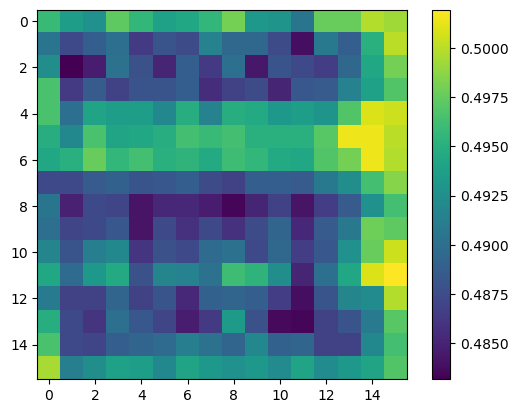

In [107]:
plt.figure()
plt.imshow(predictions[0])
plt.colorbar()

In [108]:
import tensorflow as tf

def discriminator_loss(real_output, fake_output):
    real_loss = tf.losses.binary_crossentropy(tf.ones_like(real_output), real_output, from_logits=True)
    fake_loss = tf.losses.binary_crossentropy(tf.zeros_like(fake_output), fake_output, from_logits=True)
    total_loss = real_loss + fake_loss
    return total_loss

In [109]:
# Create instances of the models
unet_model = multi_unet_model(n_classes=18, IMG_HEIGHT=256, IMG_WIDTH=256, IMG_CHANNELS=3)
generator_model = Generator(input_channels=18, output_channels=3)
discriminator_model = define_discriminator(image_shape=(256, 256, 3))  # Assuming input shape is (256, 256, 3)

# Specify optimizers for each model
unet_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

# Compile the models with their respective optimizers and loss functions
unet_model.compile(optimizer=unet_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
discriminator_model.compile(optimizer=discriminator_optimizer, loss='binary_crossentropy', loss_weights=[0.5])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv_transpose.py:94: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


In [110]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 unet_optimizer=unet_optimizer,  # Add U-Net optimizer
                                 generator=generator_model,
                                 discriminator=discriminator_model,
                                 unet=unet_model)

In [111]:
def generate_images(input_image,label):
    temp = np.reshape(input_image, (patch_size, patch_size, 3))
    temp1 = np.expand_dims(temp, axis=0)
    unet_mask = model.predict(temp1)
    #prediction1 = model[0](test_input)
    gen_output = generator(unet_mask)
    combined_output = tf.reduce_mean(gen_output[0, :, :, 0:3], axis=-1)
    plt.figure(figsize=(12, 6))
    #input_image= image_dataset[image_number]
    # Original Image
    plt.subplot(131)
    plt.imshow(input_image)
    plt.title("Original Image")

    # Predicted Mask
    plt.subplot(132)
    plt.imshow(np.argmax(unet_mask[0], axis=-1), cmap='viridis')
    plt.title("Predicted Mask")

    # Ground Truth Mask (if available)
    # Replace 'ground_truth_masks' with the actual ground truth masks dataset
    plt.subplot(133)
    plt.imshow(label[:,:,0])
    plt.title("Ground Truth Mask")

    plt.figure()
    plt.imshow((combined_output + 1) / 2)
    plt.title("generated image from unet_mask")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


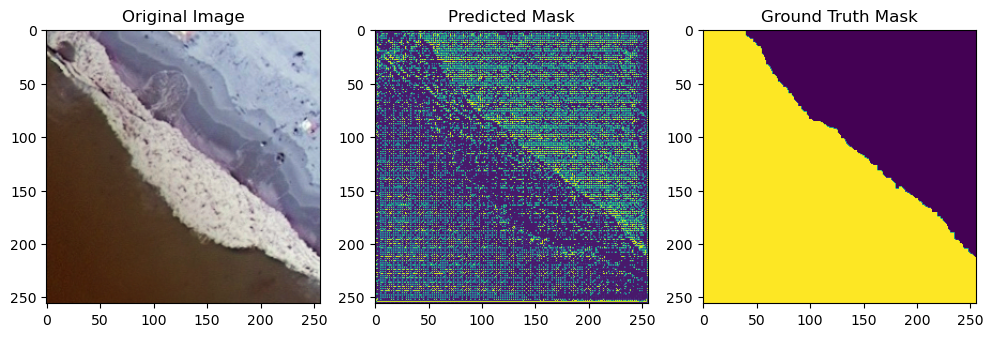

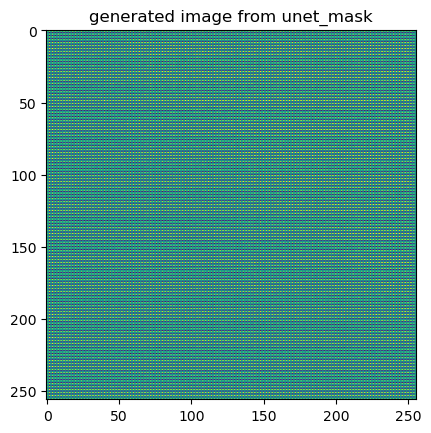

In [115]:
image_number = random.randint(0, len(image_dataset))

generate_images(image_dataset[image_number], labels[image_number])

In [116]:
import datetime
log_dir="logs/"

summary_writer = tf.summary.create_file_writer(
    log_dir + "fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

In [117]:
lambda_l1=1
lambda_adv=1
@tf.function
def train_step(input_image, target, step):
    step = int(step)  # Convert step to Python integer
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # 1. U-Net (Segmentation)
        input_image=tf.squeeze(input_image)
        target = tf.squeeze(tf.squeeze(target))
        temp = tf.squeeze(input_image)
        temp1 = tf.expand_dims(temp, axis=0)
        #unet_mask = model.predict(temp1)
        
        seg_output = unet_model(temp1, training=True)

        # 2. Generator (Image Synthesis)
        gen_output = generator_model(seg_output, training=True)

        # 3. Discriminator (Adversarial)
        input_image = tf.expand_dims(input_image, axis=0)
        target = tf.expand_dims(target, axis=0)
        disc_real_output = discriminator_model([input_image, input_image], training=True)
        disc_generated_output = discriminator_model([input_image, gen_output], training=True)

        # Segmentation Loss (U-Net)
#         target_one_hot = tf.one_hot(tf.squeeze(target), depth=18)

#     # Segmentation Loss (U-Net)
#         seg_loss = tf.keras.losses.categorical_crossentropy(target_one_hot, seg_output)
        seg_loss = tf.keras.losses.categorical_crossentropy(target, seg_output)
#         target_one_hot = tf.one_hot(tf.squeeze(target), depth=18)

#     # Resize seg_output to match the shape of target_one_hot
#         seg_output_resized = tf.image.resize(seg_output, target_one_hot.shape[1:3])

#     # Ensure both tensors have the same batch size
#         target_one_hot = tf.expand_dims(target_one_hot, axis=0)
#         seg_output_resized = tf.squeeze(tf.expand_dims(seg_output_resized, axis=0), axis=1)

#     # Segmentation Loss (U-Net)
#         seg_loss = tf.keras.losses.categorical_crossentropy(target_one_hot, seg_output_resized)
        # L1 Loss (Generator)
        # L1 Loss (Generator)
        #l1_loss = tf.reduce_mean(tf.abs(input_image - tf.cast(gen_output, tf.float64)))


        # Adversarial Loss (Discriminator)
        #disc_loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(tf.ones_like(disc_real_output), disc_real_output) +
                                   #tf.keras.losses.binary_crossentropy(tf.zeros_like(disc_generated_output), disc_generated_output))

        # Total Generator Loss
        #gen_total_loss = seg_loss + lambda_l1 * l1_loss + lambda_adv * disc_loss
        # L1 Loss (Generator)
        l1_loss = tf.reduce_mean(tf.abs(tf.cast(input_image, tf.float64) - tf.cast(gen_output, tf.float64)))

        # Adversarial Loss (Discriminator)
        disc_loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(
            tf.ones_like(disc_real_output), disc_real_output) +
            tf.keras.losses.binary_crossentropy(tf.zeros_like(disc_generated_output), disc_generated_output))

        # Total Generator Loss
        # Total Generator Loss
        gen_total_loss = tf.cast(seg_loss, tf.float64) + lambda_l1 * l1_loss + lambda_adv * tf.cast(disc_loss, tf.float64)



    # Compute gradients and update weights
    unet_gradients = gen_tape.gradient(gen_total_loss, unet_model.trainable_variables)
    generator_gradients = gen_tape.gradient(gen_total_loss, generator_model.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss, discriminator_model.trainable_variables)

    unet_optimizer.apply_gradients(zip(unet_gradients, unet_model.trainable_variables))
    generator_optimizer.apply_gradients(zip(generator_gradients, generator_model.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator_model.trainable_variables))

    # Log summaries
    with summary_writer.as_default():
        tf.summary.scalar('seg_loss', seg_loss, step=step // 1000)
        tf.summary.scalar('l1_loss', l1_loss, step=step // 1000)
        tf.summary.scalar('disc_loss', disc_loss, step=step // 1000)
        tf.summary.scalar('gen_total_loss', gen_total_loss, step=step // 1000)

In [118]:
import time
from IPython import display
from sklearn.model_selection import train_test_split
steps = 10000
# Example: Assuming you have image_dataset and mask_dataset already prepared
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(image_dataset, labels_cat, test_size=0.2, random_state=42)

# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

# Shuffle and batch the datasets
BATCH_SIZE = 1
train_dataset = train_dataset.shuffle(buffer_size=len(X_train)).batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

# Rest of the code remains the same

In [119]:
example_input, example_target = next(iter(test_dataset.take(1)))
if example_input.ndim >= 4:
    example_input = tf.squeeze(example_input, axis=0)

example_input.shape

TensorShape([256, 256, 3])

In [120]:
example_target.shape

TensorShape([1, 256, 256, 18])

In [121]:
example_target= tf.squeeze(tf.squeeze(example_target))
example_target.shape

TensorShape([256, 256, 18])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


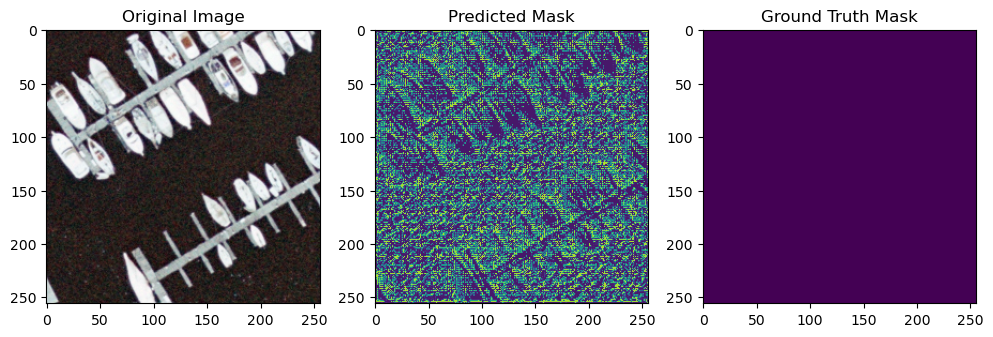

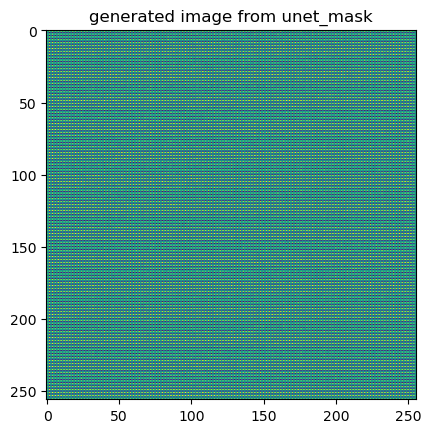

In [123]:
generate_images(example_input,example_target)

In [124]:
lambda_l1 = 1
lambda_adv = 1

@tf.function
def train_step(input_image, target, step):
    step = int(step)  # Convert step to Python integer

    # 1. U-Net (Segmentation)
    input_image = tf.squeeze(input_image)
    target = tf.squeeze(tf.squeeze(target))
    temp = tf.squeeze(input_image)
    temp1 = tf.expand_dims(temp, axis=0)
    seg_output = unet_model(temp1, training=True)

    # 2. Generator (Image Synthesis)
    gen_output = generator_model(seg_output, training=True)

    # 3. Discriminator (Adversarial)
    input_image = tf.expand_dims(input_image, axis=0)
    target = tf.expand_dims(target, axis=0)
    disc_real_output = discriminator_model([input_image, input_image], training=True)
    disc_generated_output = discriminator_model([input_image, gen_output], training=True)

    # Segmentation Loss (U-Net)
    seg_loss = tf.keras.losses.categorical_crossentropy(target, seg_output)

    # L1 Loss (Generator)
    l1_loss = tf.reduce_mean(tf.abs(tf.cast(input_image, tf.float64) - tf.cast(gen_output, tf.float64)))

    # Adversarial Loss (Discriminator)
    disc_loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(
        tf.ones_like(disc_real_output), disc_real_output) +
        tf.keras.losses.binary_crossentropy(tf.zeros_like(disc_generated_output), disc_generated_output))

    # Total Generator Loss
    gen_total_loss = tf.cast(seg_loss, tf.float64) + lambda_l1 * l1_loss + lambda_adv * tf.cast(disc_loss, tf.float64)

    # Compute gradients and update weights
    with tf.GradientTape(persistent=True) as tape:
        unet_gradients = tape.gradient(gen_total_loss, unet_model.trainable_variables)
        generator_gradients = tape.gradient(gen_total_loss, generator_model.trainable_variables)
        discriminator_gradients = tape.gradient(disc_loss, discriminator_model.trainable_variables)

    unet_optimizer.apply_gradients(zip(unet_gradients, unet_model.trainable_variables))
    generator_optimizer.apply_gradients(zip(generator_gradients, generator_model.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator_model.trainable_variables))

    # Log summaries
    with summary_writer.as_default():
        tf.summary.scalar('seg_loss', seg_loss, step=step // 1000)
        tf.summary.scalar('l1_loss', l1_loss, step=step // 1000)
        tf.summary.scalar('disc_loss', disc_loss, step=step // 1000)
        tf.summary.scalar('gen_total_loss', gen_total_loss, step=step // 1000)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


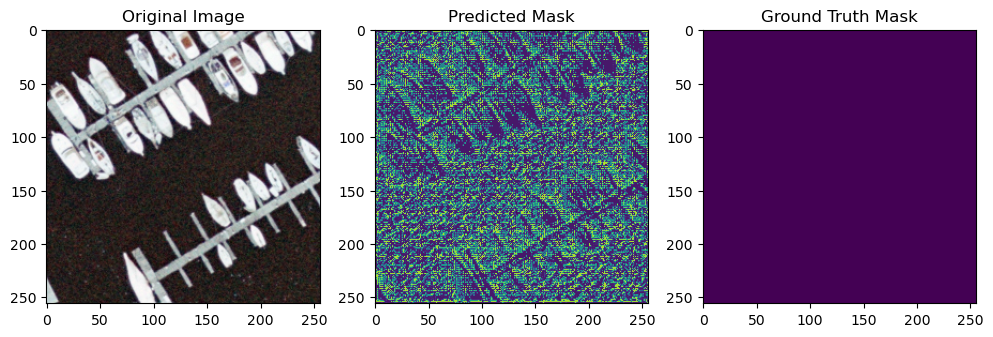

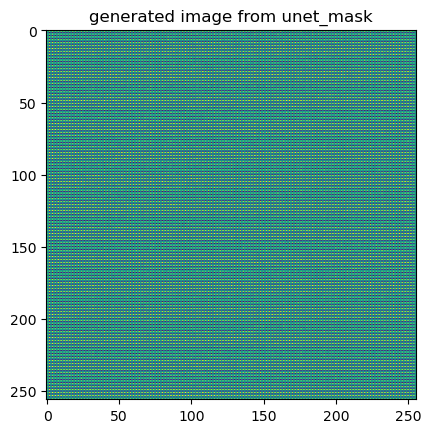

Step: 0k


/opt/anaconda3/lib/python3.12/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_286']
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)


ValueError: in user code:

    File "/var/folders/ws/kjtmfj292mx_y_mvcpvqf2pr0000gn/T/ipykernel_15937/14034818.py", line 44, in train_step  *
        unet_optimizer.apply_gradients(zip(unet_gradients, unet_model.trainable_variables))
    File "/opt/anaconda3/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py", line 383, in apply_gradients  **
        self.apply(grads, trainable_variables)
    File "/opt/anaconda3/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py", line 436, in apply
        grads, trainable_variables = self._filter_empty_gradients(
    File "/opt/anaconda3/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py", line 772, in _filter_empty_gradients
        raise ValueError("No gradients provided for any variable.")

    ValueError: No gradients provided for any variable.


In [125]:
start = time.time()

for step, (input_image, target) in train_dataset.repeat().take(steps).enumerate():
    if (step) % 1000 == 0:
        display.clear_output(wait=True)

        if step != 0:
            print(f'Time taken for 1000 steps: {time.time()-start:.2f} sec\n')

        start = time.time()

        generate_images(example_input, example_target)
        print(f"Step: {step//1000}k")

    train_step(input_image, target, step)

    # Training step
    if (step+1) % 10 == 0:
        print('.', end='', flush=True)

    # Save (checkpoint) the model every 5k steps
    if (step + 1) % 5000 == 0:
        checkpoint.save(file_prefix=checkpoint_prefix)